<a href="https://colab.research.google.com/github/vishal786-commits/machine-learning-journey/blob/main/projects/yulu-AB-testing/yulu-AB-testing-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Yulu - Hypothesis Testing**

---

## **Problem Statement**

Which factors significantly influence the demand for shared electric cycles in the Indian market, and how effectively do these factors explain variations in demand?

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm, ttest_ind, shapiro, levene, f_oneway, stats, kruskal,chi2_contingency

In [ ]:
df = pd.read_csv("yulu_dataset.csv")
df.head(10)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
5,2011-01-01 05:00:00,1,0,0,2,9.84,12.880,75,6.0032,0,1,1
6,2011-01-01 06:00:00,1,0,0,1,9.02,13.635,80,0.0000,2,0,2
7,2011-01-01 07:00:00,1,0,0,1,8.20,12.880,86,0.0000,1,2,3
8,2011-01-01 08:00:00,1,0,0,1,9.84,14.395,75,0.0000,1,7,8
9,2011-01-01 09:00:00,1,0,0,1,13.12,17.425,76,0.0000,8,6,14


## **Variable Description**


**datetime:** datetime

**season:** season (1: spring, 2: summer, 3: fall, 4: winter)

**holiday:** whether day is a holiday or not

**workingday:** if day is neither weekend nor holiday is 1, otherwise is 0.

**weather:**

1: Clear, Few clouds, partly cloudy, partly cloudy

2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist

3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light
Rain + Scattered clouds

4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog

**temp:** temperature in Celsius

**atemp:** feeling temperature in Celsius

**humidity:** humidity

**windspeed:** wind speed

**casual:** count of casual users

**registered:** count of registered users

**count:** count of total rental bikes including both casual and registered

In [ ]:
df.shape

(10886, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.drop_duplicates()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


All variables are int or float, however a closer look and reading the data description reveal that the categorical variables are "season", "holiday", "workingday", and "weather".  The numerical variables are "temp", "atemp", "humidity", "windspeed", "casual", "registered", and "count".

 Also, there are no missing or duplicate values.

##EDA by Visualisation

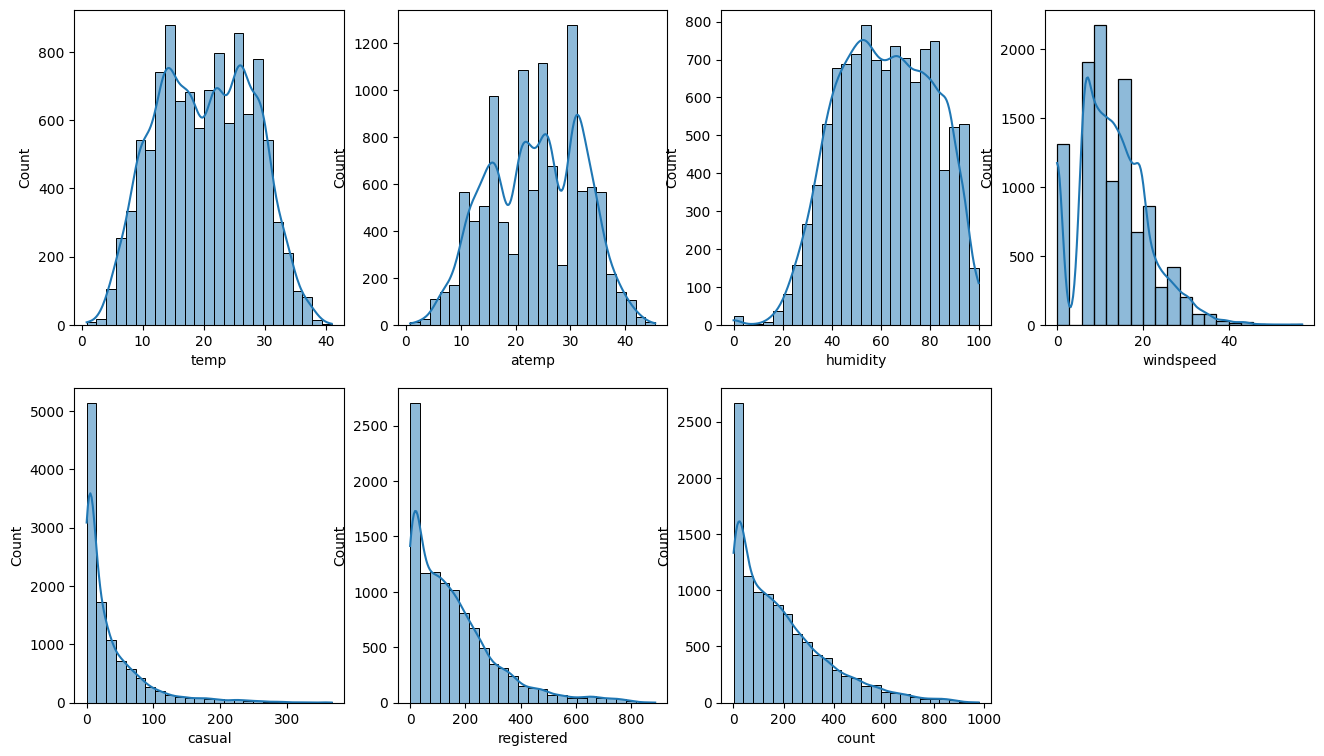

In [ ]:
# let us check the distributions for the numerical variable and countplots for the categorical variables.
fig4, axes = plt.subplots(nrows = 2, ncols = 4, figsize = (16,9))
sns.histplot(x = 'temp', data = df, ax = axes[0,0], kde =True, bins = 25)
sns.histplot(x = 'atemp', data = df, ax = axes[0,1], kde =True, bins = 25)
sns.histplot(x = 'humidity', data = df, ax = axes[0,2], kde =True, bins = 25)
sns.histplot(x = 'windspeed', data = df, ax = axes[0,3], kde =True, bins = 20)
sns.histplot(x = 'casual', data = df, ax = axes[1,0], kde =True, bins = 25)
sns.histplot(x = 'registered', data = df, ax = axes[1,1], kde =True, bins = 25)
sns.histplot(x = 'count', data = df, ax = axes[1,2], kde =True, bins = 25)
fig4.delaxes(axes[1,3])

We observe that the variables temp and atemp are normally distributed, but the others arent.

<Axes: xlabel='holiday', ylabel='count'>

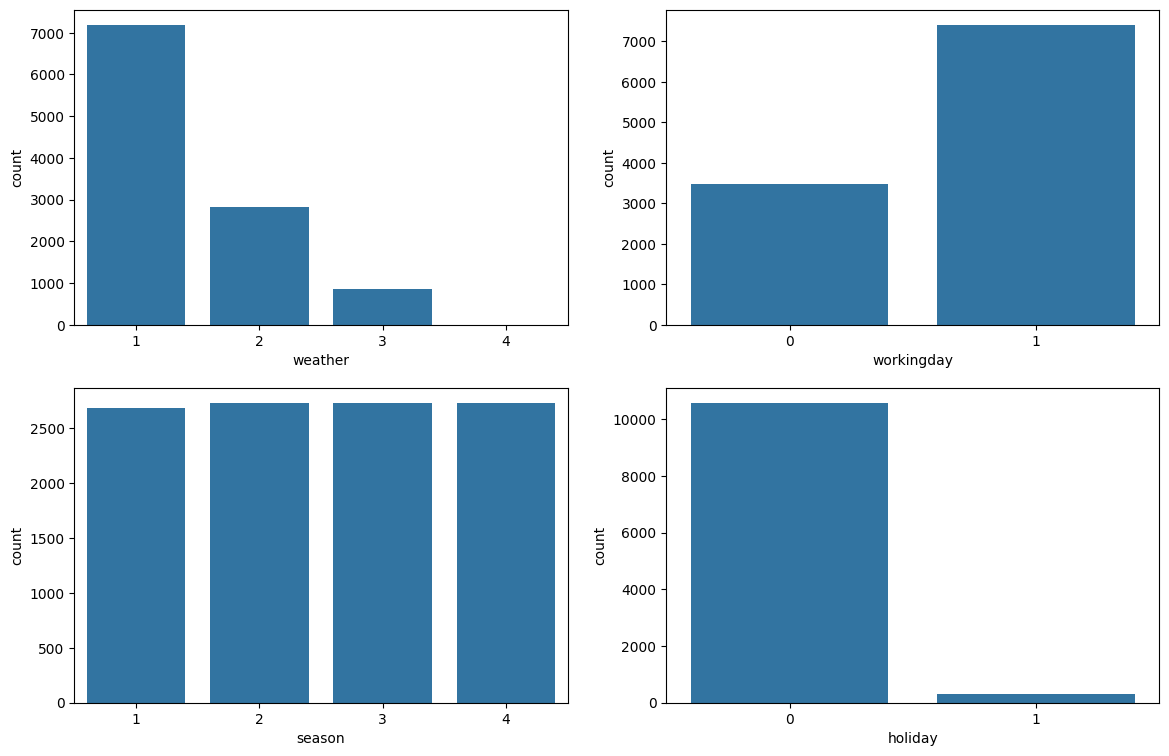

In [ ]:
fig3, axes = plt.subplots(nrows = 2, ncols= 2, figsize = (14,9))
sns.countplot(x='weather', data=df, ax = axes[0,0])
sns.countplot(x='workingday', data=df, ax = axes[0,1])
sns.countplot(x='season', data=df, ax = axes[1,0])
sns.countplot(x='holiday', data=df, ax = axes[1,1])

<Axes: xlabel='holiday', ylabel='count'>

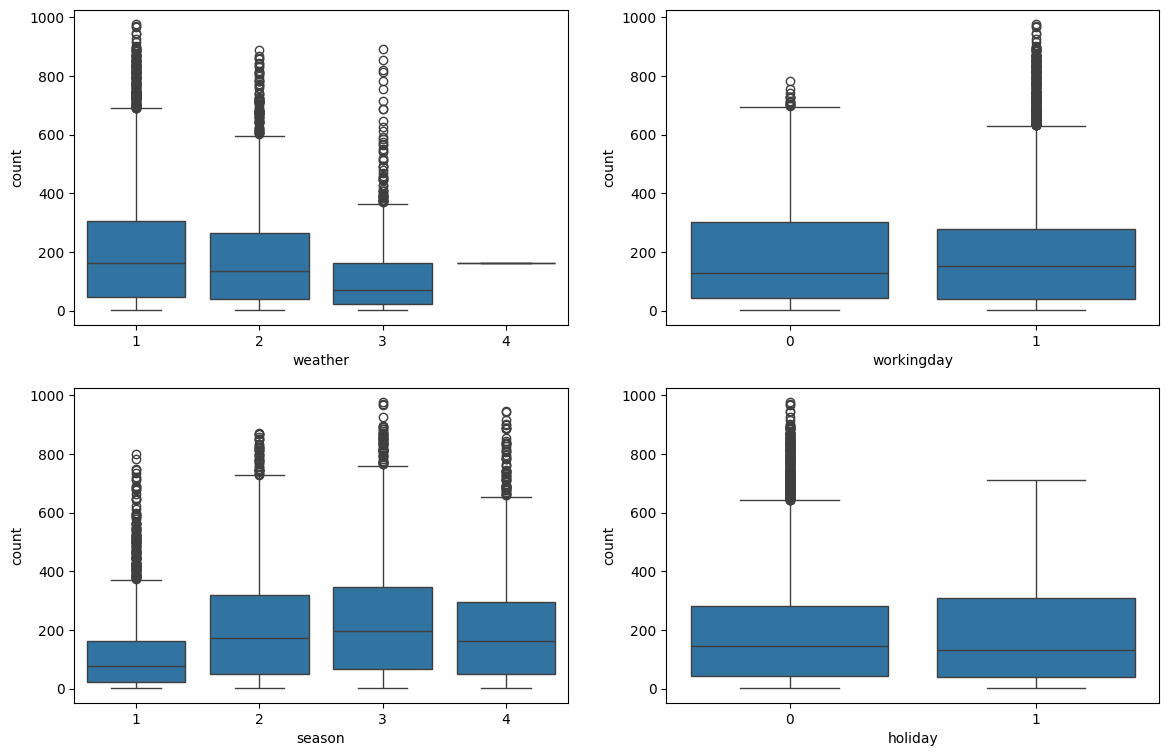

In [ ]:
#Check for Outliers in the Dataset and to remove them
fig, axes = plt.subplots(nrows = 2, ncols= 2, figsize = (14,9))
sns.boxplot(x='weather', y='count', data=df, ax = axes[0,0])
sns.boxplot(x='workingday', y='count', data=df, ax = axes[0,1])
sns.boxplot(x='season', y='count', data=df, ax = axes[1,0])
sns.boxplot(x='holiday', y='count', data=df, ax = axes[1,1])

In [ ]:
# Select numeric columns to check for outliers
numeric_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']

# Function to remove outliers using IQR
def remove_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 3 * IQR
        upper = Q3 + 3 * IQR
        # Keep only rows within the IQR bounds
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

# Apply function
df_clean = remove_outliers(df, numeric_cols)
removed = df.shape[0] - df_clean.shape[0]
# Check new shape
print("Original shape:", df.shape)
print("Shape after removing outliers:", df_clean.shape)
print("Number of rows removed:", removed)
percent_removed = (removed * 100) / df.shape[0]

print(f"Percentage of rows removed: {removed} ({percent_removed:.2f}%)")

Original shape: (10886, 12)
Shape after removing outliers: (10539, 12)
Number of rows removed: 347
Percentage of rows removed: 347 (3.19%)


<Axes: xlabel='holiday', ylabel='count'>

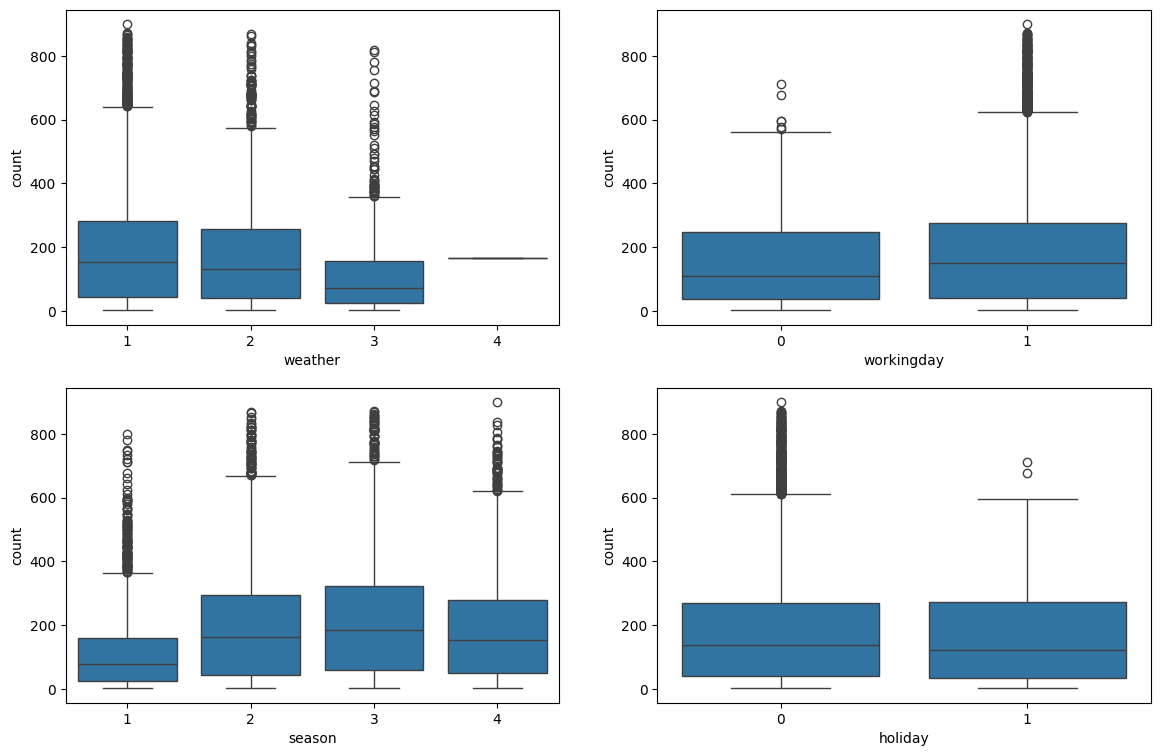

In [ ]:
fig2, axes = plt.subplots(nrows = 2, ncols= 2, figsize = (14,9))
sns.boxplot(x='weather', y='count', data=df_clean, ax = axes[0,0])
sns.boxplot(x='workingday', y='count', data=df_clean, ax = axes[0,1])
sns.boxplot(x='season', y='count', data=df_clean, ax = axes[1,0])
sns.boxplot(x='holiday', y='count', data=df_clean, ax = axes[1,1])

We have thus 347 outliers, reducing our dataset by ~3%.

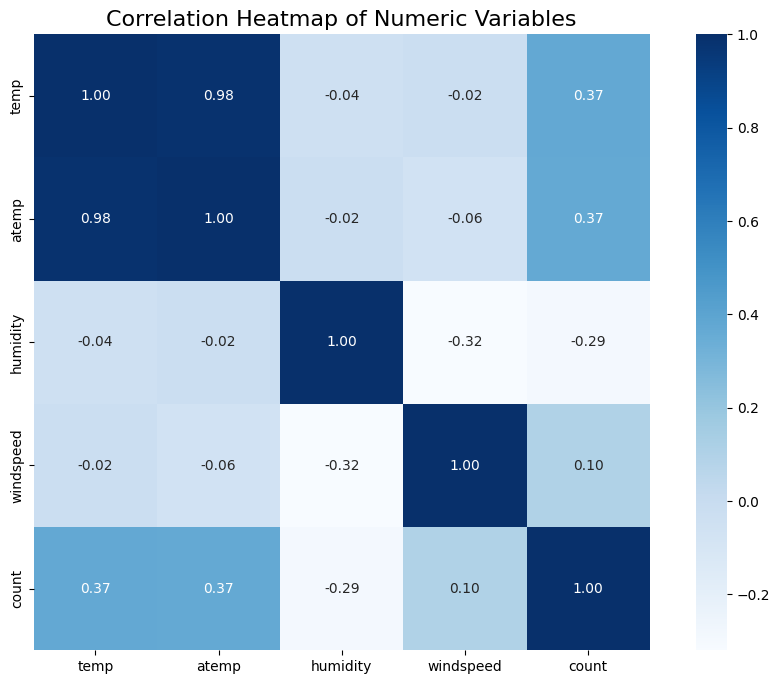

In [ ]:
# Correlation Heatmap
# Select only numeric columns

numeric_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'count']
numeric_df = df_clean[numeric_cols]

# Compute correlation matrix
corr = numeric_df.corr()

# Set figure size
plt.figure(figsize=(12, 8))

# Create heatmap
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", cbar=True, square=True)

plt.title("Correlation Heatmap of Numeric Variables", fontsize=16)
plt.show()

Since count is the total of the variables casual and registered, we disregard their correlation in this case.

Here, we observe that the variables temp and atemp have a positive correlation with count, except from casual and registered.

Humidity is a negatively correlated variable. Windspeed is one of the variables that has little correlation with count.

***Let us look at the scatterplot of count with temp and humidity***



<Axes: xlabel='count', ylabel='temp'>

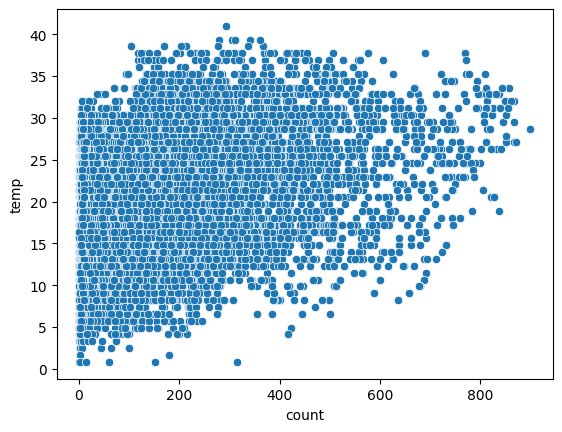

In [ ]:
sns.scatterplot(x = 'count', y = 'temp', data = df_clean)

<Axes: xlabel='count', ylabel='humidity'>

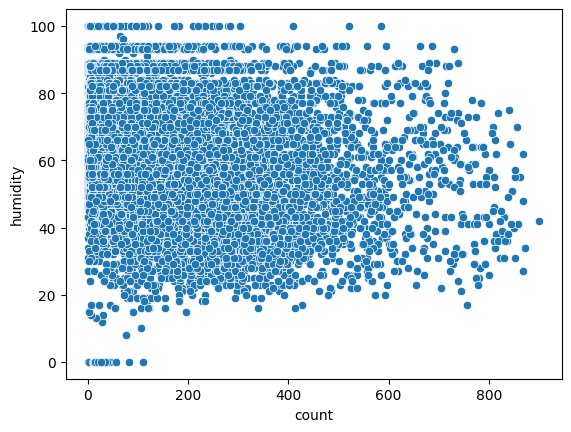

In [ ]:
sns.scatterplot(x = 'count', y = 'humidity', data = df_clean)

<Axes: xlabel='count', ylabel='windspeed'>

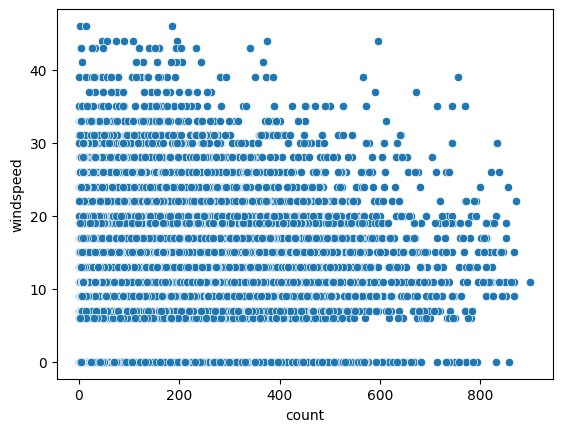

In [ ]:
sns.scatterplot(x = 'count', y = 'windspeed', data = df_clean)

There is no meaningful conclusion or inference that one can come to upon studing the corelation betweens the variables.



##**Hypothesis testing**

Let us check if there is a difference in variable Count(describing the bike rental) on **working days** and **non-workingdays**.



$H_o$: There is no difference in mean of 'count' on working days and holidays.

$H_1$: There is a significant difference in mean of 'count' on working days and holidays.


In [ ]:
df_clean.groupby('workingday')['count'].count()

,count
workingday,
0,3176
1,7363


<Axes: xlabel='count', ylabel='Density'>

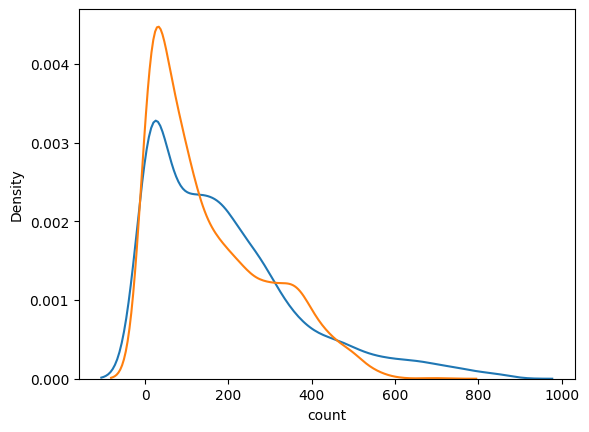

In [ ]:
# check for normality of data and equal variance

workingday = df_clean[df_clean['workingday'] == 1]['count'].sample(3175)
non_workingday = df_clean[df_clean['workingday'] == 0]['count'].sample(3175)

# print(non_workingday.shape, workingday.shape)

sns.kdeplot(workingday, legend = True)
sns.kdeplot(non_workingday, legend = True)

In [ ]:
#check for variance with Levene's Test
from scipy import stats
# Levene's test
levene_statistic, levene_pvalue = stats.levene(workingday, non_workingday)
print(f"Levene's Test P-value: {levene_pvalue}")

alpha = 0.05
if levene_pvalue < alpha:
    print("Reject the null hypothesis of equal variances (Levene's Test).")
else:
    print("Fail to reject the null hypothesis of equal variances (Levene's Test).")

Levene's Test P-value: 3.6744957453921046e-17
Reject the null hypothesis of equal variances (Levene's Test).


The data we are working with has inequal variance.

In [ ]:
# T-test 2 sample
from scipy.stats import ttest_ind

t_stat, Pval = ttest_ind(workingday, non_workingday, equal_var=False, alternative='two-sided')
alpha = 0.05

print(t_stat, round(Pval,20))


8.588015091069874 1.115e-17


Since P-value is less than alpha, we reject the null hypothesis. We conclude that there is a significant difference in the bike rental on workingdays compared to non-workingdays with 95% confidence.

Next, lets check if the bike rentals are more on working days or on non working days.

$H_o$: Mean of 'count' on working days <= holidays.

$H_1$: Mean of 'count' on working days > holidays.

In [ ]:
t_stat, Pval = ttest_ind(workingday, non_workingday, equal_var=False, alternative='greater')
alpha = 0.05

print(t_stat, Pval)

8.588015091069874 5.575458143691814e-18


The pvalue here is again less than the alpha, hence we reject the hull hypothesis. We conclude that bike rentals are higher on working days than on non working days with 95% confidence.

---

### Check if there is a significant difference in bike rental during the different weather.

note that weather type 4, which is heavy rain has no counts as one would assume cycling is usually not preferred during the rain.

$H_o$: Bike demand is the same across all weather conditions.

$H_1$: At least one weather condition has different bike demand.

In [ ]:
df_clean.groupby("weather")['count'].describe()

,count,mean,std,min,25%,50%,75%,max
weather,,,,,,,,
1,6914.0,189.774371,172.219597,1.0,44.0,151.5,283.0,900.0
2,2776.0,171.029179,159.548890,1.0,39.0,130.0,255.0,868.0
3,848.0,113.642689,129.820195,1.0,23.0,70.0,157.0,819.0
4,1.0,164.000000,NaN,164.0,164.0,164.0,164.0,164.0


let us recall the labels for weather.

**weather:**

1: Clear, Few clouds, partly cloudy, partly cloudy

2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist

3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light
Rain + Scattered clouds

4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog

In [ ]:
w1 = df_clean[df_clean['weather'] == 1]['count'].sample(848, random_state=42)
w2 = df_clean[df_clean['weather'] == 2]['count'].sample(848, random_state=42)
w3 = df_clean[df_clean['weather'] == 3]['count'].sample(848, random_state=42)

Shapiro W1: ShapiroResult(statistic=np.float64(0.9041041283488445), pvalue=np.float64(1.2268567788654812e-22))
Shapiro W2: ShapiroResult(statistic=np.float64(0.8782800279152614), pvalue=np.float64(3.2582664442558734e-25))
Shapiro W3: ShapiroResult(statistic=np.float64(0.7768059204723041), pvalue=np.float64(1.9791175481102697e-32))


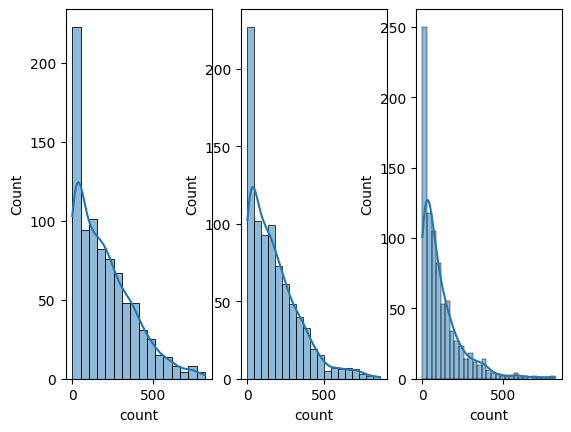

In [ ]:
# Histogram & distribution plots
fig, axes = plt.subplots(nrows = 1, ncols = 3 )
sns.histplot(w1, kde=True, ax = axes[0])
sns.histplot(w2, kde=True, ax = axes[1])
sns.histplot(w3, kde=True, ax = axes[2])


# Shapiro-Wilk test
print("Shapiro W1:", shapiro(w1))
print("Shapiro W2:", shapiro(w2))
print("Shapiro W3:", shapiro(w3))



Based on the visuals and the extremely low Pvalue, we reject the null hypothesis and conclude that the data is not normal.

In [ ]:
# Levene’s Test
stat, p = levene(w1, w2, w3)
print("Levene’s Test: stat=%.3f, p=%.3f" % (stat, p))

Levene’s Test: stat=51.264, p=0.000


The data is not of equal variance either!

Both assumptions for the ANOVA fail, but lets go ahead with **ANOVA** before doing the **Kruskal-Wallis Test**.

In [ ]:
stat, p = f_oneway(w1, w2, w3)
print('One-way ANOVA: stat=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
    print('Fail to reject H0')
else:
    print('Reject H0')


One-way ANOVA: stat=66.376, p=0.000
Reject H0


In [ ]:
stat, p = kruskal(w1, w2, w3)
print('Kruskal-Wallis Test: stat=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
    print('Fail to reject H0 → Probably same distribution')
else:
    print('Reject H0 → Distributions differ across weather')

Kruskal-Wallis Test: stat=129.733, p=0.000
Reject H0 → Distributions differ across weather


We conclude that the bike rentals are different across the weathers.

### Check for significant impact of Seasons on bike rental.

$H_o$: Bicycle demand is the same across all seasons.

$H_1$: At least one season has different bicycle demand.

In [ ]:
# Descriptive stats by season
df_clean.groupby("season")['count'].describe()

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
1,2663.0,113.043560,119.380924,1.0,24.0,78.0,160.0,801.0
2,2606.0,198.035303,178.315155,1.0,43.0,162.0,294.0,868.0
3,2603.0,217.199769,182.081147,1.0,58.0,184.0,321.0,871.0
4,2667.0,187.823022,163.174668,1.0,49.0,154.0,278.0,900.0


In [ ]:
s1 = df_clean[df_clean['season'] == 1]['count'].sample(2603, random_state=42)
s2 = df_clean[df_clean['season'] == 2]['count'].sample(2603, random_state=42)
s3 = df_clean[df_clean['season'] == 3]['count'].sample(2603, random_state=42)
s4 = df_clean[df_clean['season'] == 4]['count'].sample(2603, random_state=42)

We already know data is not Normal.

In [ ]:
stat, p = levene(s1, s2, s3, s4)
print("Levene’s Test: stat=%.3f, p=%.3f" % (stat, p))

Levene’s Test: stat=164.152, p=0.000


The variance is inequal, let us nevertheless look at an ANOVA.

In [ ]:
stat, p = f_oneway(s1, s2, s3, s4)
print('One-way ANOVA: stat=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
    print('Fail to reject H0 → Demand same across seasons')
else:
    print('Reject H0 → Demand differs across seasons')

One-way ANOVA: stat=206.316, p=0.000
Reject H0 → Demand differs across seasons


In [ ]:
stat, p = kruskal(s1, s2, s3, s4)
print('Kruskal-Wallis Test: stat=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
    print('Fail to reject H0: Demand same across seasons')
else:
    print('Reject H0: Demand differs across seasons')

Kruskal-Wallis Test: stat=601.251, p=0.000
Reject H0: Demand differs across seasons


We conclude that bike rentals differ across seasons.

Post-hoc Analysis with Tukey's HSD

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Prepare data (we don’t sample here, use full df_clean)
tukey = pairwise_tukeyhsd(endog=df_clean['count'],
                          groups=df_clean['season'],
                          alpha=0.01)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.01  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
     1      2  84.9917    0.0  71.0528  98.9306   True
     1      3 104.1562    0.0  90.2132 118.0992   True
     1      4  74.7795    0.0  60.9214  88.6376   True
     2      3  19.1645 0.0001   5.1463  33.1826   True
     2      4 -10.2123 0.1022  -24.146   3.7215  False
     3      4 -29.3767    0.0 -43.3145  -15.439   True
------------------------------------------------------


This shows the seasons 2 and 4 have very similar bike rental but the rest differ significantly

### Check if the Weather conditions are significantly different during different Seasons.

$H_o$: Weather and Season are independent → Weather conditions occur equally across seasons.

$H_1$: Weather and Season are dependent → Weather conditions differ across seasons.

season      1     2     3     4
weather                        
1        1741  1698  1832  1643
2         710   686   580   800
3         211   222   191   224
4           1     0     0     0


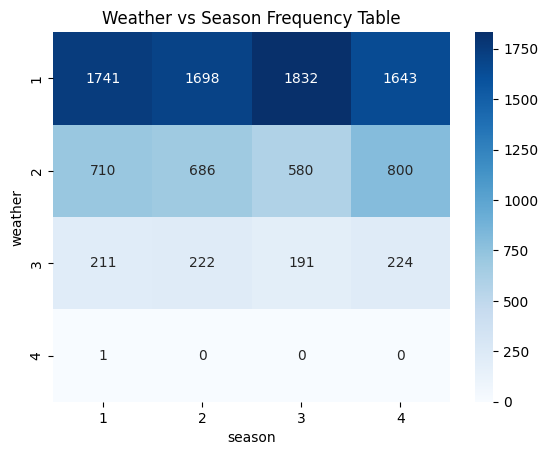

In [ ]:
# Frequency table (cross-tab)
contingency = pd.crosstab(index=df_clean['weather'], columns=df_clean['season'])
print(contingency)

# Visualize counts
sns.heatmap(contingency, annot=True, fmt="d", cmap="Blues")
plt.title("Weather vs Season Frequency Table")
plt.show()

In [ ]:
# Run Chi-Square Test of Independence
stat, p, dof, expected = chi2_contingency(contingency)

print("Chi-Square Test Results")
print(f"Chi2 Statistic = {stat:.3f}")
print(f"Degrees of Freedom = {dof}")
print(f"p-value = {p:.3f}")

Chi-Square Test Results
Chi2 Statistic = 51.335
Degrees of Freedom = 9
p-value = 0.000


In [ ]:
alpha = 0.05
if p > alpha:
    print("Fail to Reject H0 → Weather is independent of Season")
else:
    print("Reject H0 → Weather depends on Season")

Reject H0 → Weather depends on Season


We conclude that weather depends on season with 95% confidence.

## Insights and Recomendations


1. **Working Day vs Non-working Day Rentals**

* Finding: Rentals are significantly higher on working days compared to non-working days (p-value ≪ 0.05).

* Implication: Demand is commuter-driven (office goers, students, etc.), not just leisure.

* Recommendation:

  * Prioritize fleet availability on weekdays, especially peak hours (morning & evening).

  * Tie up with corporates and IT parks to ensure last-mile connectivity for employees.

2. **Weather Conditions and Rentals**

* Finding: Rentals vary significantly across weather categories (ANOVA & Kruskal-Wallis both p < 0.05).

  * Clear/Partly Cloudy weather → Highest rentals.
   
  
  
  * Heavy Rain/Snow → Almost no rentals.

* Implication: Weather directly influences demand.

* Recommendation:



  * Use dynamic pricing or discounts on slightly bad-weather days to encourage usage.

  * Temporarily reduce fleet deployment during heavy rains to cut operational costs.

3. **Seasonal Variation in Rentals**

* Finding: Rentals differ significantly across seasons (p < 0.001).


* Implication: Demand is not uniform throughout the year.

* Recommendation:

  
  * Plan maintenance downtime for Spring (low-demand period).

  * Introduce seasonal promotions to stimulate rentals in low-demand months.

4. **Weather–Season Dependency**

* Finding: Chi-Square test confirms Weather depends on Season (p < 0.001).

* Implication: Seasonal weather patterns drive expected demand fluctuations.

* Recommendation:

  * Build predictive demand models factoring in seasonal + weather forecasts.

  * Example: reduce fleet before forecasted storms, increase fleet during long dry spells.

In [ ]:
#-----------------------------------------------------The END of this Report-----------------------------------------------------
